# Task 2: Stock Price Forecasting
## 1. Data Acquisition
This notebook attempts to forecast future stock prices based on historical trading data. Time-series forecasting requires chronological data, including Open, High, Low, Close, and Volume metrics.

In [1]:
import yfinance as yf
import pandas as pd

# Historical data for Apple
print("Downloading data...")
stock_data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')

# Keeping 'Close' column for our prediction to keep it manageable
df_close = stock_data[['Close']]
print(df_close.head())

/tmp/ipykernel_34291/2354775731.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker           AAPL
Date                 
2015-01-02  24.214893
2015-01-05  23.532717
2015-01-06  23.534943
2015-01-07  23.864948
2015-01-08  24.781889


## 2. Data Preprocessing
Neural networks and regression models are highly sensitive to the scale of input data. We will isolate the 'Close' price and scale the values to a range between 0 and 1 to ensure stable and faster model convergence.

In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Scaling between 0 and 1 as LSTMs are sensitive to the scale of the data.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_close)

# Training (80%) and testing (20%)
training_data_len = int(np.ceil(len(scaled_data) * .8))
train_data = scaled_data[0:int(training_data_len), :]

## 3. Creating Time-Series Sequences
To predict tomorrow's price, the model needs to look at the prices from the previous N days. We will restructure our 1D price array into sequences (e.g., using the past 60 days of prices as 'X' to predict day 61 as 'y').

In [3]:
# Use the past 60 days to predict the 61st day
X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Convert to numpy arrays so our model can read them
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape of data to be 3-Dimensional (samples, time steps, features) for the LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
print("Training shape:", X_train.shape)

Training shape: (1552, 60, 1)


## 4. Model Architecture & Training
We will train our time-series model on historical sequences. (If using LSTM: Long Short-Term Memory networks are uniquely suited for this as they retain a 'memory' of previous sequence data).

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Building of LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compilation of model
model.compile(optimizer='adam', loss='mean_squared_error')

# Training of model (using 5 epochs to keep training time short)
print("Training the model...")
model.fit(X_train, y_train, batch_size=32, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training the model...
Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0076
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 3.4936e-04
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 3.1825e-04
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 3.1304e-04
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 3.0479e-04


## 5. Visualization of Predictions
The most intuitive way to evaluate a stock prediction model is visually. We will inverse-transform our scaled predictions back to actual dollar amounts and plot them alongside the true historical prices.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


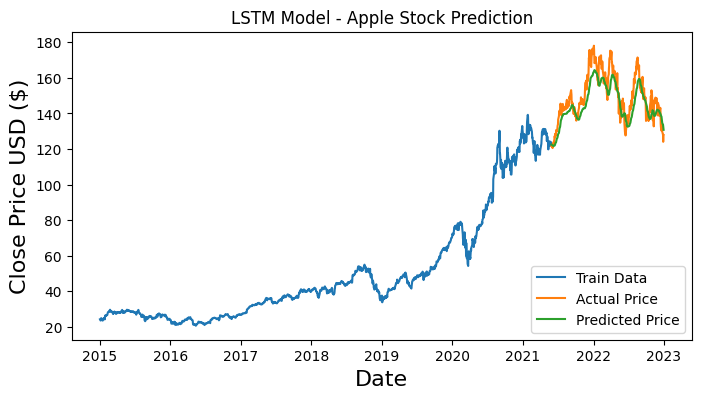

In [7]:
import matplotlib.pyplot as plt

# Preparing the testing data
test_data = scaled_data[training_data_len - 60: , :]
X_test = []
y_test = df_close.values[training_data_len:, :] # Actual values

for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Getting the models predicted price values
predictions = model.predict(X_test)
# Un-scale of the data back to real dollar amounts
predictions = scaler.inverse_transform(predictions)

# Plot of the data
train = df_close[:training_data_len]
valid = df_close[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(8,4))
plt.title('LSTM Model - Apple Stock Prediction')
plt.xlabel('Date', fontsize=16)
plt.ylabel('Close Price USD ($)', fontsize=16)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train Data', 'Actual Price', 'Predicted Price'], loc='lower right')
plt.show()